# Chest X-Ray — Complete Preprocessing Pipeline

This notebook is the **single preprocessing pipeline** for the Respira project.

## Strict workflow

```text
OLD / ORIGINAL DATASET
        │
        ▼
IMAGE ACQUISITION
        │
        ▼
CLEANING
        │
        ▼
BALANCING  (TRAIN ONLY)
        │
        ▼
CLAHE ENHANCEMENT
        │
        ▼
LUNG MASK
        │
        ▼
224 × 224
        │
        ▼
FINAL DATASET
```

### Critical dataset rules

- `Lung_Disease_Dataset` is the **only original source**.
- The original dataset is **never modified or deleted** by this notebook.
- Only these six disease classes are valid:
  - Atelectasis
  - Bacterial Pneumonia
  - Normal
  - Pulmonary Edema
  - Tuberculosis
  - Viral Pneumonia
- `random` is **not a disease class** and is rejected.
- `.ipynb_checkpoints` and other unexpected folders are rejected.
- Training is balanced by oversampling only.
- Validation and test are never balanced.
- CLAHE is applied before lung masking.
- Lung masking is followed by resize to exactly `224 × 224`.
- The final dataset is saved as 3-channel RGB PNG.
- Existing generated preprocessing data is rebuilt on each clean run, preventing stale `random` folders/files from surviving.


In [1]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

from pathlib import Path
import os
import json
import shutil
import hashlib
import random

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"C:\Users\rushi\Desktop\Respira")

# ORIGINAL DATASET — READ ONLY
ORIGINAL_DATASET = PROJECT_ROOT / "Lung_Disease_Dataset"

# ALL GENERATED DATA
DATA_ROOT = PROJECT_ROOT / "data"

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

SEED = 42
IMAGE_SIZE = (224, 224)

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

VALID_SPLITS = ["train", "val", "test"]

VALID_CLASSES = [
    "Atelectasis",
    "Bacterial Pneumonia",
    "Normal",
    "Pulmonary Edema",
    "Tuberculosis",
    "Viral Pneumonia",
]

OUTPUT_CHANNELS = 3

# IMPORTANT:
# Rebuild only generated preprocessing data.
# The original Lung_Disease_Dataset is NEVER touched.
REBUILD_GENERATED_DATA = True

# ------------------------------------------------------------
# OUTPUT DIRECTORIES
# ------------------------------------------------------------

DIRS = {
    "acquired": DATA_ROOT / "acquired",
    "cleaned": DATA_ROOT / "cleaned",
    "balanced": DATA_ROOT / "balanced",
    "clahe": DATA_ROOT / "clahe",
    "masked": DATA_ROOT / "masked",
    "processed": DATA_ROOT / "processed",
    "manifests": DATA_ROOT / "manifests",
    "reports": DATA_ROOT / "reports",
}

random.seed(SEED)
np.random.seed(SEED)

print("Project root :", PROJECT_ROOT)
print("Original     :", ORIGINAL_DATASET)
print("Data output  :", DATA_ROOT)


Project root : C:\Users\rushi\Desktop\Respira
Original     : C:\Users\rushi\Desktop\Respira\Lung_Disease_Dataset
Data output  : C:\Users\rushi\Desktop\Respira\data


## 2. Identify and validate the original source

The notebook accepts exactly one original dataset:

```text
Respira/
└── Lung_Disease_Dataset/
    ├── train/
    ├── val/
    └── test/
```

Previously processed datasets such as `*_Clean`, `*_Final`, `*_Split`, `*_ViT`, etc. are not used.


In [2]:
# ============================================================
# 2. IDENTIFY ORIGINAL SOURCE
# ============================================================

if not ORIGINAL_DATASET.exists():
    raise FileNotFoundError(
        f"Original dataset was not found:\n{ORIGINAL_DATASET}"
    )

if not ORIGINAL_DATASET.is_dir():
    raise NotADirectoryError(
        f"Original dataset path is not a directory:\n{ORIGINAL_DATASET}"
    )

forbidden_source_words = {
    "vit", "clean", "final", "split",
    "processed", "preprocessed", "balanced"
}

folder_name = ORIGINAL_DATASET.name.lower()

if any(word in folder_name for word in forbidden_source_words):
    raise RuntimeError(
        f"Safety check failed. The selected source looks processed:\n"
        f"{ORIGINAL_DATASET}"
    )

missing_splits = [
    split for split in VALID_SPLITS
    if not (ORIGINAL_DATASET / split).is_dir()
]

if missing_splits:
    raise RuntimeError(
        f"Missing required split folders: {missing_splits}"
    )

print("=" * 70)
print("ORIGINAL SOURCE VALIDATED")
print("=" * 70)
print("✓ Single original dataset")
print("✓ train/val/test found")
print("✓ Original dataset will NOT be modified")


ORIGINAL SOURCE VALIDATED
✓ Single original dataset
✓ train/val/test found
✓ Original dataset will NOT be modified


## 3. Inspect the original dataset

Inspection reports everything that exists in the source, including unwanted folders such as `random`.

**Inspection does not mean acceptance.**  
The inspection is an audit of the original source. The cleaning/acquisition rules below decide what is allowed into the generated dataset.


In [3]:
# ============================================================
# 3. DATASET INSPECTION
# ============================================================

def list_all_files(folder):
    return [
        p for p in folder.rglob("*")
        if p.is_file()
    ]

inspection_rows = []

for split in VALID_SPLITS:
    split_dir = ORIGINAL_DATASET / split

    for item in sorted(split_dir.iterdir()):
        if item.is_dir():
            files = list_all_files(item)
            image_files = [
                p for p in files
                if p.suffix.lower() in IMAGE_EXTENSIONS
            ]

            inspection_rows.append({
                "split": split,
                "class_or_folder": item.name,
                "all_files": len(files),
                "supported_images": len(image_files),
                "is_valid_class": item.name in VALID_CLASSES,
                "path": str(item),
            })

inspection_df = pd.DataFrame(inspection_rows)

print("=" * 70)
print("ORIGINAL DATASET INSPECTION")
print("=" * 70)
display(inspection_df)

print("\nTotal supported images:",
      f"{inspection_df['supported_images'].sum():,}")

print("\nUnwanted/unknown folders:")
unknown = inspection_df[
    ~inspection_df["is_valid_class"]
]
display(unknown if len(unknown) else pd.DataFrame(
    {"message": ["None"]}
))

inspection_df.to_csv(
    DIRS["reports"] / "01_original_dataset_inspection.csv",
    index=False
)

print("\n✓ Inspection report saved.")


ORIGINAL DATASET INSPECTION


,split,class_or_folder,all_files,supported_images,is_valid_class,path
0,train,.ipynb_checkpoints,0,0,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
1,train,Atelectasis,1218,1218,True,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
2,train,Bacterial Pneumonia,1205,1205,True,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
3,train,Normal,1207,1207,True,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
4,train,Pulmonary Edema,350,350,True,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
5,train,random,561,561,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
6,train,Tuberculosis,1220,1220,True,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
7,train,Viral Pneumonia,1204,1204,True,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
8,val,.ipynb_checkpoints,0,0,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
9,val,Atelectasis,406,406,True,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...



Total supported images: 11,397

Unwanted/unknown folders:


,split,class_or_folder,all_files,supported_images,is_valid_class,path
0,train,.ipynb_checkpoints,0,0,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
5,train,random,561,561,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
8,val,.ipynb_checkpoints,0,0,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
13,val,random,160,160,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
16,test,.ipynb_checkpoints,0,0,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...
21,test,random,81,81,False,C:\Users\rushi\Desktop\Respira\Lung_Disease_Da...



✓ Inspection report saved.


## 4. Optional metadata

If original metadata is available, configure `METADATA_PATH`.

The notebook does not invent patient/source identifiers. Metadata is retained separately for provenance and can be incorporated into later leakage analysis.


In [4]:
# ============================================================
# 4. OPTIONAL METADATA
# ============================================================

METADATA_PATH = None
# Example:
# METADATA_PATH = PROJECT_ROOT / "metadata.csv"

metadata_df = None

if METADATA_PATH is not None:
    METADATA_PATH = Path(METADATA_PATH)

    if not METADATA_PATH.exists():
        raise FileNotFoundError(
            f"Metadata file not found: {METADATA_PATH}"
        )

    suffix = METADATA_PATH.suffix.lower()

    if suffix == ".csv":
        metadata_df = pd.read_csv(METADATA_PATH)
    elif suffix in {".xlsx", ".xls"}:
        metadata_df = pd.read_excel(METADATA_PATH)
    elif suffix == ".json":
        metadata_df = pd.read_json(METADATA_PATH)
    else:
        raise ValueError(
            "Supported metadata formats: CSV, XLSX/XLS, JSON"
        )

    print("Metadata loaded.")
    print("Columns:", list(metadata_df.columns))
    display(metadata_df.head())

else:
    print("No metadata configured.")
    print("Labels are taken strictly from valid disease folders.")


No metadata configured.
Labels are taken strictly from valid disease folders.


## 5. Prepare generated output

Only generated folders under `data/` are rebuilt.

This is intentional: it removes stale preprocessing outputs, including any previously generated `random` directories.

**The original `Lung_Disease_Dataset` is never deleted or modified.**


In [5]:
# ============================================================
# 5. RESET GENERATED DATA
# ============================================================

if REBUILD_GENERATED_DATA:
    for directory in DIRS.values():
        if directory.exists():
            shutil.rmtree(directory)

for directory in DIRS.values():
    directory.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("GENERATED DATA RESET")
print("=" * 70)

print("✓ data/acquired rebuilt")
print("✓ data/cleaned rebuilt")
print("✓ data/balanced rebuilt")
print("✓ data/clahe rebuilt")
print("✓ data/masked rebuilt")
print("✓ data/processed rebuilt")
print("✓ manifests/reports rebuilt")
print("✓ Original dataset untouched")


GENERATED DATA RESET
✓ data/acquired rebuilt
✓ data/cleaned rebuilt
✓ data/balanced rebuilt
✓ data/clahe rebuilt
✓ data/masked rebuilt
✓ data/processed rebuilt
✓ manifests/reports rebuilt
✓ Original dataset untouched


## 6. Image acquisition

Acquisition records the original source and copies **only images belonging to the six approved disease classes**.

Important:

- `random` is recorded as rejected.
- `.ipynb_checkpoints` and other unexpected folders are recorded as rejected.
- Unsupported files are recorded as rejected.
- No `random` directory is created under `data/acquired/`.


In [6]:
# ============================================================
# 6. IMAGE ACQUISITION
# ============================================================

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)

    return digest.hexdigest()


acquisition_rows = []
acquisition_rejections = []

for split in VALID_SPLITS:

    split_dir = ORIGINAL_DATASET / split

    for class_dir in sorted(
        [p for p in split_dir.iterdir() if p.is_dir()]
    ):

        class_name = class_dir.name

        # ----------------------------------------------------
        # REJECT UNKNOWN FOLDERS
        # ----------------------------------------------------

        if class_name not in VALID_CLASSES:

            for path in class_dir.rglob("*"):

                if path.is_file():

                    acquisition_rejections.append({
                        "split": split,
                        "label": class_name,
                        "original_path": str(path),
                        "reason": "unknown_class_or_folder"
                    })

            continue

        # ----------------------------------------------------
        # ACQUIRE VALID CLASS IMAGES
        # ----------------------------------------------------

        output_class_dir = (
            DIRS["acquired"] /
            split /
            class_name
        )

        output_class_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        for src in sorted(class_dir.rglob("*")):

            if not src.is_file():
                continue

            if src.suffix.lower() not in IMAGE_EXTENSIONS:

                acquisition_rejections.append({
                    "split": split,
                    "label": class_name,
                    "original_path": str(src),
                    "reason": "unsupported_extension"
                })

                continue

            digest = sha256_file(src)

            destination = (
                output_class_dir /
                f"{digest[:16]}_{src.stem}.png"
            )

            # Copy source bytes at acquisition stage.
            # Cleaning will validate/standardize later.
            shutil.copy2(src, destination)

            acquisition_rows.append({
                "split": split,
                "label": class_name,
                "original_path": str(src),
                "acquired_path": str(destination),
                "filename": src.name,
                "sha256": digest,
                "source_extension": src.suffix.lower(),
            })


acquired_manifest = pd.DataFrame(acquisition_rows)

acquisition_rejections_df = pd.DataFrame(
    acquisition_rejections
)

acquired_manifest.to_csv(
    DIRS["manifests"] / "02_acquired_manifest.csv",
    index=False
)

acquisition_rejections_df.to_csv(
    DIRS["reports"] / "02_acquisition_rejections.csv",
    index=False
)

print("=" * 70)
print("IMAGE ACQUISITION COMPLETE")
print("=" * 70)

print("Acquired valid images:",
      f"{len(acquired_manifest):,}")

print("Rejected during acquisition:",
      f"{len(acquisition_rejections_df):,}")

print("\nRejected folders/reasons:")
if len(acquisition_rejections_df):
    display(
        acquisition_rejections_df["reason"]
        .value_counts()
        .rename_axis("reason")
        .reset_index(name="count")
    )

print("\n✓ random was NOT copied.")
print("✓ Unknown folders were NOT copied.")


IMAGE ACQUISITION COMPLETE
Acquired valid images: 10,595
Rejected during acquisition: 802

Rejected folders/reasons:


,reason,count
0,unknown_class_or_folder,802



✓ random was NOT copied.
✓ Unknown folders were NOT copied.


## 7. Cleaning

Cleaning is a strict quality-control gate.

Checks:

- zero-byte files
- unreadable/corrupt images
- unsupported formats
- exact duplicate files
- valid disease labels only

The original dataset is untouched. Invalid files are reported rather than silently disappearing.


In [7]:
# ============================================================
# 7. CLEANING
# ============================================================

def validate_image(path):
    if not path.exists():
        return False, "missing_file"

    if path.stat().st_size == 0:
        return False, "zero_byte"

    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        return False, "unsupported_extension"

    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            img.load()

    except Exception:
        return False, "corrupt_or_unreadable"

    return True, "valid"


cleaning_rows = []
seen_hashes = {}

for _, row in tqdm(
    acquired_manifest.iterrows(),
    total=len(acquired_manifest),
    desc="Cleaning acquired images"
):

    src = Path(row["acquired_path"])
    label = str(row["label"])
    split = str(row["split"])

    # Safety: acquisition should never contain an invalid class.
    if label not in VALID_CLASSES:
        cleaning_rows.append({
            **row.to_dict(),
            "status": "rejected",
            "reason": "invalid_class"
        })
        continue

    valid, reason = validate_image(src)

    if not valid:
        cleaning_rows.append({
            **row.to_dict(),
            "status": "rejected",
            "reason": reason
        })
        continue

    digest = sha256_file(src)

    # Exact duplicate control across the complete dataset.
    # This prevents identical images from crossing splits.
    if digest in seen_hashes:

        cleaning_rows.append({
            **row.to_dict(),
            "sha256": digest,
            "status": "rejected",
            "reason": "exact_duplicate",
            "duplicate_of": seen_hashes[digest]
        })

        continue

    seen_hashes[digest] = str(src)

    # --------------------------------------------------------
    # Standardize cleaned image to grayscale PNG.
    # CLAHE operates on grayscale chest X-rays.
    # --------------------------------------------------------

    output_dir = (
        DIRS["cleaned"] /
        split /
        label
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_path = (
        output_dir /
        f"{digest[:16]}.png"
    )

    with Image.open(src) as img:
        gray = img.convert("L")
        gray.save(output_path, format="PNG")

    cleaning_rows.append({
        **row.to_dict(),
        "sha256": digest,
        "cleaned_path": str(output_path),
        "status": "valid",
        "reason": "accepted"
    })


cleaning_df = pd.DataFrame(cleaning_rows)

clean_manifest = cleaning_df[
    cleaning_df["status"] == "valid"
].copy()

rejected_df = cleaning_df[
    cleaning_df["status"] == "rejected"
].copy()


clean_manifest.to_csv(
    DIRS["manifests"] / "03_clean_manifest.csv",
    index=False
)

rejected_df.to_csv(
    DIRS["reports"] / "03_cleaning_rejections.csv",
    index=False
)

print("=" * 70)
print("CLEANING COMPLETE")
print("=" * 70)

print("Valid images   :", f"{len(clean_manifest):,}")
print("Rejected images:", f"{len(rejected_df):,}")

print("\nRejection reasons:")
if len(rejected_df):
    display(
        rejected_df["reason"]
        .value_counts()
        .rename_axis("reason")
        .reset_index(name="count")
    )
else:
    print("None")

# Hard safety gate
if set(clean_manifest["label"]) - set(VALID_CLASSES):
    raise RuntimeError("Invalid class reached clean_manifest.")

if "random" in set(clean_manifest["label"].astype(str).str.lower()):
    raise RuntimeError(
        "CRITICAL: random reached clean_manifest."
    )

print("\n✓ Only six approved disease classes remain.")
print("✓ random is absent from clean_manifest.")


Cleaning acquired images:   0%|          | 0/10595 [00:00<?, ?it/s]

CLEANING COMPLETE
Valid images   : 10,587
Rejected images: 8

Rejection reasons:


,reason,count
0,exact_duplicate,8



✓ Only six approved disease classes remain.
✓ random is absent from clean_manifest.


## 8. Leakage / duplicate audit

Exact duplicate images are checked using SHA-256.

The cleaning stage already prevents an exact duplicate from being retained twice, so this section verifies the final clean manifest independently.


In [8]:
# ============================================================
# 8. DUPLICATE / LEAKAGE AUDIT
# ============================================================

duplicate_hashes = (
    clean_manifest["sha256"]
    .value_counts()
)

duplicate_hashes = duplicate_hashes[
    duplicate_hashes > 1
]

cross_split_duplicates = (
    clean_manifest
    .groupby("sha256")["split"]
    .nunique()
)

cross_split_duplicates = cross_split_duplicates[
    cross_split_duplicates > 1
]

print("=" * 70)
print("DUPLICATE / LEAKAGE AUDIT")
print("=" * 70)

print(
    "Duplicate hashes remaining:",
    len(duplicate_hashes)
)

print(
    "Hashes crossing train/val/test:",
    len(cross_split_duplicates)
)

if len(duplicate_hashes) == 0:
    print("✓ No exact duplicates remain.")

if len(cross_split_duplicates) == 0:
    print("✓ No exact duplicate hash crosses splits.")

audit = (
    clean_manifest
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
)

display(audit)

audit.to_csv(
    DIRS["reports"] / "04_clean_distribution.csv",
    index=False
)


DUPLICATE / LEAKAGE AUDIT
Duplicate hashes remaining: 0
Hashes crossing train/val/test: 0
✓ No exact duplicates remain.
✓ No exact duplicate hash crosses splits.


,split,label,count
0,test,Atelectasis,404
1,test,Bacterial Pneumonia,403
2,test,Normal,404
3,test,Pulmonary Edema,50
4,test,Tuberculosis,408
5,test,Viral Pneumonia,403
6,train,Atelectasis,1213
7,train,Bacterial Pneumonia,1205
8,train,Normal,1207
9,train,Pulmonary Edema,350


## 9. Training-only balancing

Only the training split is balanced.

The target is the largest valid training class. Minority classes are oversampled with replacement.

Validation and test remain exactly at their cleaned counts.

`random` is explicitly forbidden from entering this stage.


In [9]:
# ============================================================
# 9. TRAINING-ONLY BALANCING
# ============================================================

train_df = clean_manifest[
    (clean_manifest["split"] == "train") &
    (clean_manifest["label"].isin(VALID_CLASSES))
].copy()

val_df = clean_manifest[
    (clean_manifest["split"] == "val") &
    (clean_manifest["label"].isin(VALID_CLASSES))
].copy()

test_df = clean_manifest[
    (clean_manifest["split"] == "test") &
    (clean_manifest["label"].isin(VALID_CLASSES))
].copy()


# ------------------------------------------------------------
# HARD SAFETY CHECK
# ------------------------------------------------------------

for name, df in {
    "train": train_df,
    "val": val_df,
    "test": test_df
}.items():

    invalid = set(df["label"]) - set(VALID_CLASSES)

    if invalid:
        raise RuntimeError(
            f"Invalid classes in {name}: {sorted(invalid)}"
        )

    if "random" in set(df["label"].astype(str).str.lower()):
        raise RuntimeError(
            f"CRITICAL: random found in cleaned {name}."
        )


# ------------------------------------------------------------
# ORIGINAL TRAIN DISTRIBUTION
# ------------------------------------------------------------

original_train_distribution = (
    train_df["label"]
    .value_counts()
    .reindex(VALID_CLASSES, fill_value=0)
    .rename_axis("label")
    .reset_index(name="count")
)

display(original_train_distribution)

target_count = int(
    original_train_distribution["count"].max()
)

if target_count == 0:
    raise RuntimeError("No valid training images found.")

print(
    f"\nTarget training count per class: {target_count:,}"
)


# ------------------------------------------------------------
# BUILD BALANCED MANIFEST
# ------------------------------------------------------------

balanced_rows = []

for class_name in VALID_CLASSES:

    class_df = train_df[
        train_df["label"] == class_name
    ].copy()

    current_count = len(class_df)

    if current_count == 0:
        raise RuntimeError(
            f"Training class has zero images: {class_name}"
        )

    if current_count < target_count:

        extra = class_df.sample(
            n=target_count - current_count,
            replace=True,
            random_state=SEED
        )

        balanced_class = pd.concat(
            [class_df, extra],
            ignore_index=True
        )

        method = "oversampled"

    else:

        balanced_class = class_df.copy()
        method = "unchanged"

    for balance_index, (_, row) in enumerate(
        balanced_class.iterrows()
    ):

        balanced_rows.append({
            "split": "train",
            "label": class_name,
            "cleaned_path": row["cleaned_path"],
            "source_path": row["original_path"],
            "sha256": row["sha256"],
            "balance_index": balance_index,
            "balancing_method": method,
            "seed": SEED
        })


balanced_train = pd.DataFrame(balanced_rows)

balanced_train.to_csv(
    DIRS["manifests"] / "05_balanced_train_manifest.csv",
    index=False
)


# ------------------------------------------------------------
# BALANCED DISTRIBUTION
# ------------------------------------------------------------

balanced_distribution = (
    balanced_train["label"]
    .value_counts()
    .reindex(VALID_CLASSES, fill_value=0)
    .rename_axis("label")
    .reset_index(name="count")
)

display(balanced_distribution)


# ------------------------------------------------------------
# HARD SAFETY CHECKS
# ------------------------------------------------------------

if "random" in set(
    balanced_train["label"].astype(str).str.lower()
):
    raise RuntimeError(
        "CRITICAL: random entered balanced training."
    )

if set(balanced_train["label"]) != set(VALID_CLASSES):
    raise RuntimeError(
        "Balanced training does not contain exactly the six valid classes."
    )

if balanced_distribution["count"].nunique() != 1:
    raise RuntimeError(
        "Balanced training counts are not equal."
    )

print("\n✓ Training-only balancing complete.")
print("✓ random excluded.")
print("✓ Validation untouched.")
print("✓ Test untouched.")
print(
    f"✓ Balanced training total: {len(balanced_train):,}"
)


,label,count
0,Atelectasis,1213
1,Bacterial Pneumonia,1205
2,Normal,1207
3,Pulmonary Edema,350
4,Tuberculosis,1220
5,Viral Pneumonia,1204



Target training count per class: 1,220


,label,count
0,Atelectasis,1220
1,Bacterial Pneumonia,1220
2,Normal,1220
3,Pulmonary Edema,1220
4,Tuberculosis,1220
5,Viral Pneumonia,1220



✓ Training-only balancing complete.
✓ random excluded.
✓ Validation untouched.
✓ Test untouched.
✓ Balanced training total: 7,320


## 10. Create physical balanced training data

The balanced manifest is converted into physical files.

Validation and test are **not** duplicated or balanced.


In [10]:
# ============================================================
# 10. CREATE BALANCED TRAIN DATA
# ============================================================

balanced_train_paths = []

for idx, row in tqdm(
    balanced_train.iterrows(),
    total=len(balanced_train),
    desc="Creating balanced training images"
):

    src = Path(row["cleaned_path"])
    label = str(row["label"])

    if label not in VALID_CLASSES:
        raise RuntimeError(
            f"Invalid label encountered: {label}"
        )

    dst_dir = (
        DIRS["balanced"] /
        "train" /
        label
    )

    dst_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    dst = (
        dst_dir /
        f"{idx:08d}_{row['sha256'][:16]}.png"
    )

    shutil.copy2(src, dst)

    balanced_train_paths.append(str(dst))


balanced_train["balanced_path"] = balanced_train_paths

balanced_train.to_csv(
    DIRS["manifests"] / "06_balanced_train_paths.csv",
    index=False
)

print("Balanced training directory:")
print(DIRS["balanced"] / "train")

print("\n✓ No validation/test images were balanced.")


Creating balanced training images:   0%|          | 0/7320 [00:00<?, ?it/s]

Balanced training directory:
C:\Users\rushi\Desktop\Respira\data\balanced\train

✓ No validation/test images were balanced.


## 11. CLAHE enhancement

CLAHE is applied to grayscale images.

Parameters:

- Clip limit: `2.0`
- Tile grid: `8 × 8`

**CLAHE does not resize the image.**

The resize happens only after lung masking.


In [11]:
# ============================================================
# 11. CLAHE
# ============================================================

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_GRID_SIZE
)


def clahe_image(input_path, output_path):

    image = cv2.imread(
        str(input_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Cannot read image: {input_path}"
        )

    enhanced = clahe.apply(image)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    if not cv2.imwrite(
        str(output_path),
        enhanced
    ):
        raise IOError(
            f"Failed to write CLAHE image: {output_path}"
        )


# ------------------------------------------------------------
# Build processing manifest
#
# TRAIN = balanced
# VAL/TEST = cleaned, untouched distributions
# ------------------------------------------------------------

train_process = balanced_train.copy()
train_process["processing_split"] = "train"
train_process["processing_source"] = train_process["balanced_path"]

val_process = val_df.copy()
val_process["processing_split"] = "val"
val_process["processing_source"] = val_process["cleaned_path"]

test_process = test_df.copy()
test_process["processing_split"] = "test"
test_process["processing_source"] = test_process["cleaned_path"]


processing_manifest = pd.concat(
    [
        train_process,
        val_process,
        test_process
    ],
    ignore_index=True,
    sort=False
)


# ------------------------------------------------------------
# FINAL CLASS SAFETY CHECK
# ------------------------------------------------------------

invalid = (
    set(processing_manifest["label"].astype(str))
    - set(VALID_CLASSES)
)

if invalid:
    raise RuntimeError(
        f"Invalid classes in processing manifest: {sorted(invalid)}"
    )

if "random" in set(
    processing_manifest["label"].astype(str).str.lower()
):
    raise RuntimeError(
        "CRITICAL: random entered CLAHE processing."
    )


# ------------------------------------------------------------
# APPLY CLAHE
# ------------------------------------------------------------

clahe_paths = []

for idx, row in tqdm(
    processing_manifest.iterrows(),
    total=len(processing_manifest),
    desc="Applying CLAHE"
):

    src = Path(row["processing_source"])

    unique_id = hashlib.sha1(
        f"{row['processing_split']}|{idx}|{src}".encode()
    ).hexdigest()[:16]

    dst = (
        DIRS["clahe"]
        / str(row["processing_split"])
        / str(row["label"])
        / f"{unique_id}.png"
    )

    clahe_image(src, dst)

    clahe_paths.append(str(dst))


processing_manifest["clahe_path"] = clahe_paths

processing_manifest.to_csv(
    DIRS["manifests"] / "07_clahe_manifest.csv",
    index=False
)

print("✓ CLAHE complete.")
print("✓ Image dimensions were NOT changed in this stage.")


Applying CLAHE:   0%|          | 0/11508 [00:00<?, ?it/s]

✓ CLAHE complete.
✓ Image dimensions were NOT changed in this stage.


## 12. Lung masking

A reproducible OpenCV heuristic mask is applied to the CLAHE image.

This is a preprocessing heuristic, **not a clinical-grade lung segmentation model**.


In [22]:
# ============================================================
# 12. LUNG MASKING
# ============================================================

def create_lung_mask(gray):

    img = cv2.normalize(
        gray,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    blur = cv2.GaussianBlur(
        img,
        (5, 5),
        0
    )

    _, threshold = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (9, 9)
    )

    mask = cv2.morphologyEx(
        threshold,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    h, w = mask.shape

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    candidates = []

    for component_id in range(1, num_labels):

        x, y, cw, ch, area = stats[component_id]
        cx, cy = centroids[component_id]

        if area < 0.03 * h * w:
            continue

        if (
            0.10 * w <= cx <= 0.90 * w
            and
            0.10 * h <= cy <= 0.92 * h
        ):
            candidates.append(
                (area, component_id)
            )

    candidates.sort(reverse=True)

    lung_mask = np.zeros_like(mask)

    for _, component_id in candidates[:2]:

        lung_mask[
            labels == component_id
        ] = 255

    # --------------------------------------------------------
    # FALLBACK CENTRAL CHEST REGION
    # --------------------------------------------------------

    if np.count_nonzero(lung_mask) < 0.05 * h * w:

        yy, xx = np.ogrid[:h, :w]

        cx = w / 2
        cy = h * 0.52

        rx = w * 0.38
        ry = h * 0.40

        ellipse = (
            ((xx - cx) ** 2 / rx ** 2)
            +
            ((yy - cy) ** 2 / ry ** 2)
            <= 1
        )

        lung_mask[ellipse] = 255

    # Smooth mask edges
    lung_mask = cv2.GaussianBlur(
        lung_mask,
        (7, 7),
        0
    )

    return lung_mask


def apply_lung_mask(gray):

    mask = create_lung_mask(gray)

    mask_float = (
        mask.astype(np.float32) / 255.0
    )

    masked = (
        gray.astype(np.float32)
        * mask_float
    )

    masked = np.clip(
        masked,
        0,
        255
    ).astype(np.uint8)

    return masked, mask


print("✓ Lung mask functions ready.")

✓ Lung mask functions ready.


## 13. Mask + resize to 224×224

The final processing order is:

```text
CLAHE
   ↓
LUNG MASK
   ↓
RESIZE 224 × 224
   ↓
3-channel RGB PNG
```

This is the first stage where the images are standardized to exactly `224 × 224`.


In [24]:
# ============================================================
# 13. LUNG MASK + 224×224 FINAL DATASET
# ============================================================

def create_final_image(input_path, output_path):

    # --------------------------------------------------------
    # READ CLAHE IMAGE
    # --------------------------------------------------------

    gray = cv2.imread(
        str(input_path),
        cv2.IMREAD_GRAYSCALE
    )

    if gray is None:
        raise ValueError(
            f"Cannot read CLAHE image: {input_path}"
        )

    # --------------------------------------------------------
    # APPLY LUNG MASK
    # --------------------------------------------------------

    masked, mask = apply_lung_mask(gray)

    # --------------------------------------------------------
    # RESIZE TO 224 × 224
    # --------------------------------------------------------

    resized = cv2.resize(
        masked,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    # --------------------------------------------------------
    # CONVERT TO REQUIRED CHANNELS
    # --------------------------------------------------------

    if OUTPUT_CHANNELS == 3:

        final = cv2.cvtColor(
            resized,
            cv2.COLOR_GRAY2RGB
        )

    elif OUTPUT_CHANNELS == 1:

        final = resized

    else:

        raise ValueError(
            f"Unsupported OUTPUT_CHANNELS: {OUTPUT_CHANNELS}"
        )

    # --------------------------------------------------------
    # CREATE FINAL OUTPUT DIRECTORY
    # --------------------------------------------------------

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # --------------------------------------------------------
    # SAVE FINAL IMAGE
    # --------------------------------------------------------

    if OUTPUT_CHANNELS == 3:

        image_to_save = cv2.cvtColor(
            final,
            cv2.COLOR_RGB2BGR
        )

    else:

        image_to_save = final

    success = cv2.imwrite(
        str(output_path),
        image_to_save
    )

    if not success:
        raise IOError(
            f"Failed to save final image: {output_path}"
        )

    return mask, final


# ============================================================
# PROCESS COMPLETE DATASET
# ============================================================

processed_paths = []
mask_paths = []

for idx, row in tqdm(
    processing_manifest.iterrows(),
    total=len(processing_manifest),
    desc="Lung masking + resizing"
):

    label = str(row["label"])
    split = str(row["processing_split"])

    # --------------------------------------------------------
    # SAFETY CHECK — VALID CLASSES ONLY
    # --------------------------------------------------------

    if label not in VALID_CLASSES:

        raise RuntimeError(
            f"Invalid class reached final processing: {label}"
        )

    # --------------------------------------------------------
    # SAFETY CHECK — NEVER ALLOW RANDOM
    # --------------------------------------------------------

    if label.lower() == "random":

        raise RuntimeError(
            "CRITICAL: random reached final processing."
        )

    # --------------------------------------------------------
    # CLAHE SOURCE
    # --------------------------------------------------------

    clahe_path = Path(
        row["clahe_path"]
    )

    if not clahe_path.exists():

        raise FileNotFoundError(
            f"CLAHE image not found:\n{clahe_path}"
        )

    # --------------------------------------------------------
    # CREATE UNIQUE ID
    # --------------------------------------------------------

    unique_id = hashlib.sha1(
        f"{split}|{idx}|{clahe_path}".encode()
    ).hexdigest()[:16]

    # --------------------------------------------------------
    # FINAL IMAGE PATH
    # --------------------------------------------------------

    final_path = (
        DIRS["processed"]
        / split
        / label
        / f"{unique_id}.png"
    )

    # --------------------------------------------------------
    # MASK PATH
    # --------------------------------------------------------

    mask_path = (
        DIRS["masked"]
        / split
        / label
        / f"{unique_id}_mask.png"
    )

    # --------------------------------------------------------
    # CREATE FINAL IMAGE
    # --------------------------------------------------------

    mask, final = create_final_image(
        clahe_path,
        final_path
    )

    # --------------------------------------------------------
    # CREATE MASK DIRECTORY
    # --------------------------------------------------------

    mask_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # --------------------------------------------------------
    # SAVE LUNG MASK
    # --------------------------------------------------------

    mask_success = cv2.imwrite(
        str(mask_path),
        mask
    )

    if not mask_success:

        raise IOError(
            f"Failed to save lung mask:\n{mask_path}"
        )

    # --------------------------------------------------------
    # VERIFY MASK
    # --------------------------------------------------------

    if not mask_path.exists():

        raise RuntimeError(
            f"Lung mask was not created:\n{mask_path}"
        )

    # --------------------------------------------------------
    # VERIFY FINAL IMAGE
    # --------------------------------------------------------

    if not final_path.exists():

        raise RuntimeError(
            f"Final image was not created:\n{final_path}"
        )

    # --------------------------------------------------------
    # VERIFY FINAL IMAGE SIZE
    # --------------------------------------------------------

    saved_final = cv2.imread(
        str(final_path),
        cv2.IMREAD_UNCHANGED
    )

    if saved_final is None:

        raise RuntimeError(
            f"Cannot read saved final image:\n{final_path}"
        )

    if saved_final.shape[:2] != tuple(IMAGE_SIZE):

        raise RuntimeError(
            f"Wrong final resolution:\n"
            f"{final_path}\n"
            f"Expected: {IMAGE_SIZE}\n"
            f"Actual: {saved_final.shape[:2]}"
        )

    # --------------------------------------------------------
    # STORE PATHS
    # --------------------------------------------------------

    processed_paths.append(
        str(final_path)
    )

    mask_paths.append(
        str(mask_path)
    )


# ============================================================
# UPDATE MANIFEST
# ============================================================

processing_manifest["processed_path"] = (
    processed_paths
)

processing_manifest["mask_path"] = (
    mask_paths
)

processing_manifest.to_csv(
    DIRS["manifests"]
    / "08_final_processed_manifest.csv",
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("✓ FINAL DATASET CREATED")
print("=" * 70)

print(
    "Images processed :",
    len(processing_manifest)
)

print(
    "Final location   :",
    DIRS["processed"]
)

print(
    "Mask location    :",
    DIRS["masked"]
)

print(
    "Resolution       :",
    IMAGE_SIZE
)

print(
    "Channels         :",
    OUTPUT_CHANNELS
)

print(
    "Manifest         :",
    DIRS["manifests"]
    / "08_final_processed_manifest.csv"
)

print("=" * 70)

Lung masking + resizing:   0%|          | 0/11508 [00:00<?, ?it/s]


✓ FINAL DATASET CREATED
Images processed : 11508
Final location   : C:\Users\rushi\Desktop\Respira\data\processed
Mask location    : C:\Users\rushi\Desktop\Respira\data\masked
Resolution       : (224, 224)
Channels         : 3
Manifest         : C:\Users\rushi\Desktop\Respira\data\manifests\08_final_processed_manifest.csv


## 14. Final dataset verification

The final dataset must satisfy all of the following:

- exactly six disease classes
- no `random`
- no unexpected class folders
- every image readable
- exactly `224 × 224`
- exactly 3 channels
- training balanced
- validation/test retain cleaned distributions


In [25]:
# ============================================================
# 14. FINAL DATASET VERIFICATION
# ============================================================

verification_rows = []

for _, row in tqdm(
    processing_manifest.iterrows(),
    total=len(processing_manifest),
    desc="Verifying final dataset"
):

    processed_path = Path(
        row["processed_path"]
    )

    mask_path = Path(
        row["mask_path"]
    )

    try:

        # ----------------------------------------------------
        # READ FINAL IMAGE
        # ----------------------------------------------------

        img = cv2.imread(
            str(processed_path),
            cv2.IMREAD_UNCHANGED
        )

        if img is None:
            raise ValueError(
                "Unreadable final image"
            )

        height, width = img.shape[:2]

        channels = (
            1
            if len(img.shape) == 2
            else img.shape[2]
        )

        final_valid = (
            height == IMAGE_SIZE[0]
            and
            width == IMAGE_SIZE[1]
            and
            channels == OUTPUT_CHANNELS
        )

        # ----------------------------------------------------
        # READ MASK
        # ----------------------------------------------------

        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            raise ValueError(
                "Unreadable or missing lung mask"
            )

        mask_height, mask_width = mask.shape[:2]

        mask_valid = (
            mask_height > 0
            and
            mask_width > 0
        )

        # ----------------------------------------------------
        # CHECK FINAL IMAGE EXISTS
        # ----------------------------------------------------

        processed_exists = processed_path.exists()

        # ----------------------------------------------------
        # CHECK MASK EXISTS
        # ----------------------------------------------------

        mask_exists = mask_path.exists()

        # ----------------------------------------------------
        # CHECK CLASS
        # ----------------------------------------------------

        class_valid = (
            str(row["label"]) in VALID_CLASSES
        )

        # ----------------------------------------------------
        # CHECK RANDOM
        # ----------------------------------------------------

        random_valid = (
            str(row["label"]).lower()
            != "random"
        )

        # ----------------------------------------------------
        # OVERALL VALIDITY
        # ----------------------------------------------------

        valid = (
            processed_exists
            and
            mask_exists
            and
            final_valid
            and
            mask_valid
            and
            class_valid
            and
            random_valid
        )

        verification_rows.append({

            "processed_path":
                str(processed_path),

            "mask_path":
                str(mask_path),

            "split":
                row["processing_split"],

            "label":
                row["label"],

            "height":
                height,

            "width":
                width,

            "channels":
                channels,

            "mask_height":
                mask_height,

            "mask_width":
                mask_width,

            "processed_exists":
                processed_exists,

            "mask_exists":
                mask_exists,

            "final_valid":
                final_valid,

            "mask_valid":
                mask_valid,

            "class_valid":
                class_valid,

            "random_valid":
                random_valid,

            "valid":
                valid
        })

    except Exception as exc:

        verification_rows.append({

            "processed_path":
                str(processed_path),

            "mask_path":
                str(mask_path),

            "split":
                row["processing_split"],

            "label":
                row["label"],

            "height":
                0,

            "width":
                0,

            "channels":
                0,

            "mask_height":
                0,

            "mask_width":
                0,

            "processed_exists":
                processed_path.exists(),

            "mask_exists":
                mask_path.exists(),

            "final_valid":
                False,

            "mask_valid":
                False,

            "class_valid":
                str(row["label"]) in VALID_CLASSES,

            "random_valid":
                str(row["label"]).lower()
                != "random",

            "valid":
                False,

            "error":
                str(exc)
        })


# ============================================================
# CREATE VERIFICATION DATAFRAME
# ============================================================

verification_df = pd.DataFrame(
    verification_rows
)


# ============================================================
# SAVE REPORT
# ============================================================

verification_df.to_csv(
    DIRS["reports"]
    / "09_final_verification.csv",
    index=False
)


# ============================================================
# CHECK MANIFEST CLASSES
# ============================================================

manifest_classes = set(
    processing_manifest["label"]
    .astype(str)
)

invalid_classes = (
    manifest_classes
    - set(VALID_CLASSES)
)


# ============================================================
# CHECK RANDOM IN MANIFEST
# ============================================================

random_present_manifest = any(
    processing_manifest["label"]
    .astype(str)
    .str.lower()
    .eq("random")
)


# ============================================================
# CHECK PHYSICAL RANDOM DIRECTORIES
# ============================================================

random_directories = []

for root_dir in [
    DIRS["acquired"],
    DIRS["cleaned"],
    DIRS["balanced"],
    DIRS["clahe"],
    DIRS["masked"],
    DIRS["processed"]
]:

    if root_dir.exists():

        for path in root_dir.rglob("*"):

            if (
                path.is_dir()
                and
                path.name.lower() == "random"
            ):
                random_directories.append(
                    str(path)
                )


# ============================================================
# CHECK PHYSICAL CHECKPOINT DIRECTORIES
# ============================================================

checkpoint_directories = []

for root_dir in [
    DIRS["acquired"],
    DIRS["cleaned"],
    DIRS["balanced"],
    DIRS["clahe"],
    DIRS["masked"],
    DIRS["processed"]
]:

    if root_dir.exists():

        for path in root_dir.rglob("*"):

            if (
                path.is_dir()
                and
                path.name == ".ipynb_checkpoints"
            ):
                checkpoint_directories.append(
                    str(path)
                )


# ============================================================
# INVALID FINAL IMAGES
# ============================================================

invalid_images = verification_df[
    ~verification_df["valid"]
]


# ============================================================
# SUMMARY
# ============================================================

print("=" * 70)
print("FINAL DATASET VERIFICATION")
print("=" * 70)

print(
    "\nTotal records:",
    len(verification_df)
)

print(
    "Valid records:",
    int(verification_df["valid"].sum())
)

print(
    "Invalid records:",
    len(invalid_images)
)

print(
    "Missing masks:",
    int(
        (~verification_df["mask_exists"])
        .sum()
    )
)

print(
    "Invalid masks:",
    int(
        (~verification_df["mask_valid"])
        .sum()
    )
)

print(
    "Invalid final images:",
    int(
        (~verification_df["final_valid"])
        .sum()
    )
)

print(
    "Random in manifest:",
    random_present_manifest
)

print(
    "Physical random directories:",
    len(random_directories)
)

print(
    "Checkpoint directories:",
    len(checkpoint_directories)
)


# ============================================================
# DISPLAY VALIDITY
# ============================================================

display(
    verification_df[
        "valid"
    ]
    .value_counts()
    .rename_axis("valid")
    .reset_index(
        name="count"
    )
)


# ============================================================
# HARD SAFETY CHECKS
# ============================================================

if invalid_classes:

    raise RuntimeError(
        "Invalid classes in final dataset:\n"
        f"{sorted(invalid_classes)}"
    )


if random_present_manifest:

    raise RuntimeError(
        "CRITICAL: random is present "
        "in processing manifest."
    )


if random_directories:

    raise RuntimeError(
        "CRITICAL: random directories "
        "exist in generated data:\n"
        + "\n".join(random_directories)
    )


if checkpoint_directories:

    raise RuntimeError(
        "CRITICAL: .ipynb_checkpoints "
        "directories exist in generated data:\n"
        + "\n".join(checkpoint_directories)
    )


if len(invalid_images) > 0:

    raise RuntimeError(
        f"{len(invalid_images)} invalid "
        "records detected."
    )


# ============================================================
# FINAL SUCCESS
# ============================================================

print("\n" + "=" * 70)
print("✓ FINAL DATASET PASSED ALL CHECKS")
print("=" * 70)

print("✓ All final images are readable.")
print("✓ All final images are 224×224.")
print("✓ All final images have correct channels.")
print("✓ All lung masks exist and are readable.")
print("✓ All six classes are valid.")
print("✓ random is absent from the manifest.")
print("✓ random directories are absent.")
print("✓ .ipynb_checkpoints are absent.")
print("✓ No invalid records detected.")

print("=" * 70)

Verifying final dataset:   0%|          | 0/11508 [00:00<?, ?it/s]

FINAL DATASET VERIFICATION

Total records: 11508
Valid records: 11508
Invalid records: 0
Missing masks: 0
Invalid masks: 0
Invalid final images: 0
Random in manifest: False
Physical random directories: 0
Checkpoint directories: 0


,valid,count
0,True,11508



✓ FINAL DATASET PASSED ALL CHECKS
✓ All final images are readable.
✓ All final images are 224×224.
✓ All final images have correct channels.
✓ All lung masks exist and are readable.
✓ All six classes are valid.
✓ random is absent from the manifest.
✓ random directories are absent.
✓ .ipynb_checkpoints are absent.
✓ No invalid records detected.


## 15. Final class distribution

This is the distribution to use for the experiments.

Training is balanced. Validation and test are **not** balanced.


In [26]:
# ============================================================
# 15. FINAL CLASS DISTRIBUTION
# ============================================================

final_distribution = (
    processing_manifest
    .groupby(
        ["processing_split", "label"]
    )
    .size()
    .reset_index(name="count")
)

# ------------------------------------------------------------
# Force the expected six-class view
# ------------------------------------------------------------

invalid_classes = (
    set(final_distribution["label"].astype(str))
    - set(VALID_CLASSES)
)

if invalid_classes:
    raise RuntimeError(
        f"Invalid final classes: {sorted(invalid_classes)}"
    )

if "random" in set(
    final_distribution["label"].astype(str).str.lower()
):
    raise RuntimeError(
        "CRITICAL: random found in final distribution."
    )

display(final_distribution)


# ------------------------------------------------------------
# SPLIT TOTALS
# ------------------------------------------------------------

split_summary = (
    processing_manifest
    .groupby("processing_split")
    .size()
    .rename_axis("split")
    .reset_index(name="images")
)

display(split_summary)


# ------------------------------------------------------------
# TRAIN BALANCE CHECK
# ------------------------------------------------------------

train_final = final_distribution[
    final_distribution["processing_split"] == "train"
]

if train_final["count"].nunique() != 1:
    raise RuntimeError(
        "Final training distribution is not balanced."
    )


# ------------------------------------------------------------
# SAVE REPORTS
# ------------------------------------------------------------

final_distribution.to_csv(
    DIRS["reports"] / "10_final_class_distribution.csv",
    index=False
)

split_summary.to_csv(
    DIRS["reports"] / "11_final_split_summary.csv",
    index=False
)

print("\n✓ Final distribution verified.")
print("✓ Training balanced.")
print("✓ Validation/test untouched.")
print("✓ random absent.")


,processing_split,label,count
0,test,Atelectasis,404
1,test,Bacterial Pneumonia,403
2,test,Normal,404
3,test,Pulmonary Edema,50
4,test,Tuberculosis,408
5,test,Viral Pneumonia,403
6,train,Atelectasis,1220
7,train,Bacterial Pneumonia,1220
8,train,Normal,1220
9,train,Pulmonary Edema,1220


,split,images
0,test,2072
1,train,7320
2,val,2116



✓ Final distribution verified.
✓ Training balanced.
✓ Validation/test untouched.
✓ random absent.


## 16. Visual quality check

The panel shows:

```text
Original → CLAHE → Lung Mask → Final 224×224
```


In [27]:
# ============================================================
# DIAGNOSTIC — FIND WHICH IMAGE IS MISSING
# ============================================================

row = processing_manifest.iloc[0]

paths = {
    "original": Path(row["processing_source"]),
    "clahe": Path(row["clahe_path"]),
    "mask": Path(row["mask_path"]),
    "final": Path(row["processed_path"]),
}

print("=" * 70)
print("VISUAL CHECK DIAGNOSTIC")
print("=" * 70)

for name, path in paths.items():

    print(f"\n{name.upper()}")
    print("Path   :", path)
    print("Exists :", path.exists())

    if path.exists():
        print("Size   :", path.stat().st_size, "bytes")

        img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)

        print("Loaded :", img is not None)

        if img is not None:
            print("Shape  :", img.shape)
            print("Dtype  :", img.dtype)

print("\n" + "=" * 70)

VISUAL CHECK DIAGNOSTIC

ORIGINAL
Path   : C:\Users\rushi\Desktop\Respira\data\balanced\train\Atelectasis\00000000_0846948c46a06137.png
Exists : True
Size   : 22934 bytes
Loaded : True
Shape  : (173, 232)
Dtype  : uint8

CLAHE
Path   : C:\Users\rushi\Desktop\Respira\data\clahe\train\Atelectasis\9dfd45ff42ef798d.png
Exists : True
Size   : 27203 bytes
Loaded : True
Shape  : (173, 232)
Dtype  : uint8

MASK
Path   : C:\Users\rushi\Desktop\Respira\data\masked\train\Atelectasis\c834f9a8bdf5c0ae_mask.png
Exists : True
Size   : 6627 bytes
Loaded : True
Shape  : (173, 232)
Dtype  : uint8

FINAL
Path   : C:\Users\rushi\Desktop\Respira\data\processed\train\Atelectasis\c834f9a8bdf5c0ae.png
Exists : True
Size   : 44093 bytes
Loaded : True
Shape  : (224, 224, 3)
Dtype  : uint8



VISUAL QUALITY CHECK

Original :
C:\Users\rushi\Desktop\Respira\data\balanced\train\Atelectasis\00000000_0846948c46a06137.png

CLAHE :
C:\Users\rushi\Desktop\Respira\data\clahe\train\Atelectasis\9dfd45ff42ef798d.png

Mask :
C:\Users\rushi\Desktop\Respira\data\masked\train\Atelectasis\c834f9a8bdf5c0ae_mask.png

Final :
C:\Users\rushi\Desktop\Respira\data\processed\train\Atelectasis\c834f9a8bdf5c0ae.png


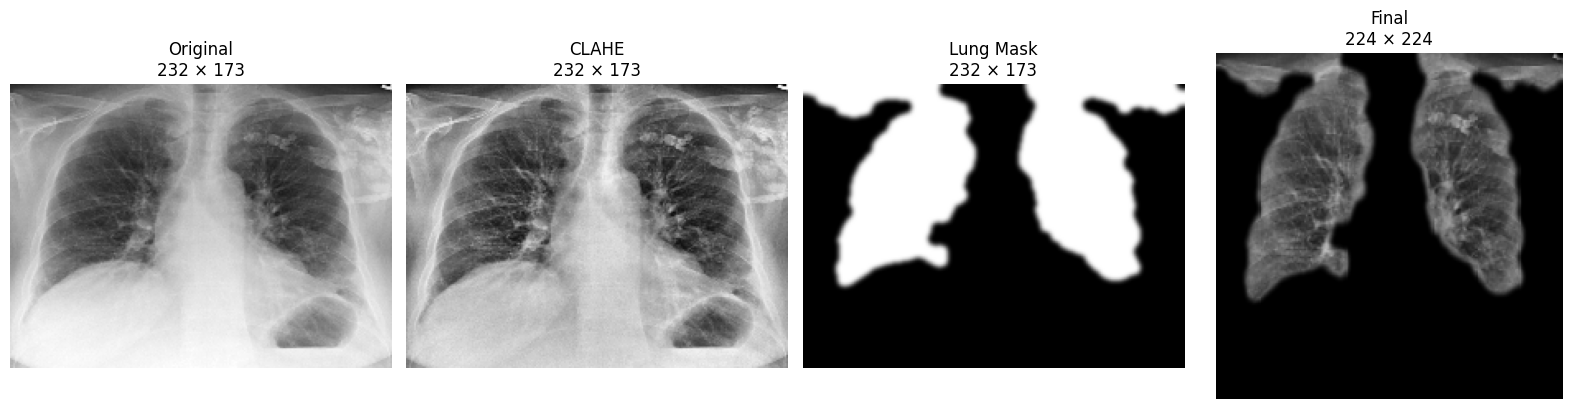


PIPELINE INFORMATION
Split       : train
Label       : Atelectasis

Original:
  Shape : (173, 232)

CLAHE:
  Shape : (173, 232)

Lung Mask:
  Shape : (173, 232)
  Min   : 0
  Max   : 255
  Non-zero pixels : 16746

Final:
  Shape : (224, 224, 3)
  Height: 224
  Width : 224
  Channels: 3
  Dtype : uint8

Final path:
  C:\Users\rushi\Desktop\Respira\data\processed\train\Atelectasis\c834f9a8bdf5c0ae.png

Mask path:
  C:\Users\rushi\Desktop\Respira\data\masked\train\Atelectasis\c834f9a8bdf5c0ae_mask.png

✓ VISUAL QUALITY CHECK PASSED
✓ Original image loaded
✓ CLAHE image loaded
✓ Lung mask loaded
✓ Lung mask is non-empty
✓ Final image loaded
✓ Final resolution is 224 × 224
✓ Final image has 3 channels


In [29]:
# ============================================================
# 16. VISUAL QUALITY CHECK
# ============================================================

def show_pipeline_example(row_index=0):

    # --------------------------------------------------------
    # CHECK ROW INDEX
    # --------------------------------------------------------

    if len(processing_manifest) == 0:
        raise RuntimeError(
            "processing_manifest is empty."
        )

    if row_index < 0 or row_index >= len(processing_manifest):
        raise IndexError(
            f"row_index must be between 0 and "
            f"{len(processing_manifest) - 1}"
        )

    row = processing_manifest.iloc[row_index]

    # --------------------------------------------------------
    # PATHS
    # --------------------------------------------------------

    original_path = Path(
        row["processing_source"]
    )

    clahe_path = Path(
        row["clahe_path"]
    )

    final_path = Path(
        row["processed_path"]
    )

    # --------------------------------------------------------
    # MASK PATH
    #
    # First use the manifest path.
    # If it does not exist, search the corresponding
    # masked directory.
    # --------------------------------------------------------

    mask_path = None

    if "mask_path" in processing_manifest.columns:

        candidate = Path(
            row["mask_path"]
        )

        if candidate.exists():
            mask_path = candidate

    # Fallback search
    if mask_path is None:

        masked_dir = (
            DIRS["masked"]
            / str(row["processing_split"])
            / str(row["label"])
        )

        if masked_dir.exists():

            # Try matching the final image ID first
            final_stem = final_path.stem

            matching_masks = list(
                masked_dir.glob(
                    f"{final_stem}_mask.png"
                )
            )

            if matching_masks:
                mask_path = matching_masks[0]

            else:

                mask_candidates = list(
                    masked_dir.glob("*_mask.png")
                )

                if len(mask_candidates) == 1:
                    mask_path = mask_candidates[0]

    # --------------------------------------------------------
    # PRINT PATH INFORMATION
    # --------------------------------------------------------

    print("=" * 70)
    print("VISUAL QUALITY CHECK")
    print("=" * 70)

    print("\nOriginal :")
    print(original_path)

    print("\nCLAHE :")
    print(clahe_path)

    print("\nMask :")
    print(mask_path)

    print("\nFinal :")
    print(final_path)

    # --------------------------------------------------------
    # CHECK FILE EXISTENCE
    # --------------------------------------------------------

    if not original_path.exists():

        raise FileNotFoundError(
            f"Original image does not exist:\n"
            f"{original_path}"
        )

    if not clahe_path.exists():

        raise FileNotFoundError(
            f"CLAHE image does not exist:\n"
            f"{clahe_path}"
        )

    if mask_path is None:

        raise FileNotFoundError(
            "Lung mask could not be located.\n\n"
            f"Expected directory:\n"
            f"{DIRS['masked'] / str(row['processing_split']) / str(row['label'])}"
        )

    if not mask_path.exists():

        raise FileNotFoundError(
            f"Lung mask does not exist:\n"
            f"{mask_path}"
        )

    if not final_path.exists():

        raise FileNotFoundError(
            f"Final image does not exist:\n"
            f"{final_path}"
        )

    # --------------------------------------------------------
    # LOAD ORIGINAL
    # --------------------------------------------------------

    original = cv2.imread(
        str(original_path),
        cv2.IMREAD_GRAYSCALE
    )

    if original is None:

        raise ValueError(
            f"Cannot load original image:\n"
            f"{original_path}"
        )

    # --------------------------------------------------------
    # LOAD CLAHE
    # --------------------------------------------------------

    clahe_img = cv2.imread(
        str(clahe_path),
        cv2.IMREAD_GRAYSCALE
    )

    if clahe_img is None:

        raise ValueError(
            f"Cannot load CLAHE image:\n"
            f"{clahe_path}"
        )

    # --------------------------------------------------------
    # LOAD MASK
    # --------------------------------------------------------

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:

        raise ValueError(
            f"Cannot load lung mask:\n"
            f"{mask_path}"
        )

    # --------------------------------------------------------
    # LOAD FINAL IMAGE
    # --------------------------------------------------------

    final = cv2.imread(
        str(final_path),
        cv2.IMREAD_COLOR
    )

    if final is None:

        raise ValueError(
            f"Cannot load final image:\n"
            f"{final_path}"
        )

    # ========================================================
    # VALIDATION
    # ========================================================

    # --------------------------------------------------------
    # ORIGINAL / CLAHE / MASK DIMENSIONS
    # --------------------------------------------------------

    if original.shape != clahe_img.shape:

        raise ValueError(
            "Original and CLAHE dimensions do not match.\n"
            f"Original: {original.shape}\n"
            f"CLAHE:    {clahe_img.shape}"
        )

    if original.shape != mask.shape:

        raise ValueError(
            "Original and lung mask dimensions do not match.\n"
            f"Original: {original.shape}\n"
            f"Mask:     {mask.shape}"
        )

    # --------------------------------------------------------
    # FINAL 224 × 224 CHECK
    #
    # IMPORTANT:
    # final.shape is (224, 224, 3)
    # final.shape[:2] is (224, 224)
    #
    # IMAGE_SIZE is also (224, 224)
    # --------------------------------------------------------

    expected_height = IMAGE_SIZE[0]
    expected_width = IMAGE_SIZE[1]

    actual_height = final.shape[0]
    actual_width = final.shape[1]

    if (
        actual_height != expected_height
        or
        actual_width != expected_width
    ):

        raise ValueError(
            f"Final image is not "
            f"{expected_height}×{expected_width}.\n"
            f"Actual shape: {final.shape}"
        )

    # --------------------------------------------------------
    # FINAL CHANNEL CHECK
    # --------------------------------------------------------

    if len(final.shape) != 3:

        raise ValueError(
            "Final image is not a 3-channel image.\n"
            f"Actual shape: {final.shape}"
        )

    final_channels = final.shape[2]

    if final_channels != OUTPUT_CHANNELS:

        raise ValueError(
            f"Final image has incorrect number of channels.\n"
            f"Expected: {OUTPUT_CHANNELS}\n"
            f"Actual:   {final_channels}"
        )

    # --------------------------------------------------------
    # MASK VALIDITY
    # --------------------------------------------------------

    if np.count_nonzero(mask) == 0:

        raise ValueError(
            "Lung mask is completely empty."
        )

    # --------------------------------------------------------
    # CONVERT FINAL BGR → RGB
    # --------------------------------------------------------

    final_rgb = cv2.cvtColor(
        final,
        cv2.COLOR_BGR2RGB
    )

    # ========================================================
    # DISPLAY PIPELINE
    # ========================================================

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    # --------------------------------------------------------
    # ORIGINAL
    # --------------------------------------------------------

    axes[0].imshow(
        original,
        cmap="gray"
    )

    axes[0].set_title(
        f"Original\n"
        f"{original.shape[1]} × {original.shape[0]}"
    )

    # --------------------------------------------------------
    # CLAHE
    # --------------------------------------------------------

    axes[1].imshow(
        clahe_img,
        cmap="gray"
    )

    axes[1].set_title(
        f"CLAHE\n"
        f"{clahe_img.shape[1]} × {clahe_img.shape[0]}"
    )

    # --------------------------------------------------------
    # LUNG MASK
    # --------------------------------------------------------

    axes[2].imshow(
        mask,
        cmap="gray"
    )

    axes[2].set_title(
        f"Lung Mask\n"
        f"{mask.shape[1]} × {mask.shape[0]}"
    )

    # --------------------------------------------------------
    # FINAL
    # --------------------------------------------------------

    axes[3].imshow(
        final_rgb
    )

    axes[3].set_title(
        f"Final\n"
        f"{final.shape[1]} × {final.shape[0]}"
    )

    # --------------------------------------------------------
    # REMOVE AXES
    # --------------------------------------------------------

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # PIPELINE INFORMATION
    # ========================================================

    print("\n" + "=" * 70)
    print("PIPELINE INFORMATION")
    print("=" * 70)

    print(
        "Split       :",
        row["processing_split"]
    )

    print(
        "Label       :",
        row["label"]
    )

    print("\nOriginal:")
    print(
        "  Shape :",
        original.shape
    )

    print("\nCLAHE:")
    print(
        "  Shape :",
        clahe_img.shape
    )

    print("\nLung Mask:")
    print(
        "  Shape :",
        mask.shape
    )

    print(
        "  Min   :",
        int(mask.min())
    )

    print(
        "  Max   :",
        int(mask.max())
    )

    print(
        "  Non-zero pixels :",
        int(np.count_nonzero(mask))
    )

    print("\nFinal:")
    print(
        "  Shape :",
        final.shape
    )

    print(
        "  Height:",
        final.shape[0]
    )

    print(
        "  Width :",
        final.shape[1]
    )

    print(
        "  Channels:",
        final.shape[2]
    )

    print(
        "  Dtype :",
        final.dtype
    )

    print("\nFinal path:")
    print(
        " ",
        final_path
    )

    print("\nMask path:")
    print(
        " ",
        mask_path
    )

    # ========================================================
    # SUCCESS
    # ========================================================

    print("\n" + "=" * 70)
    print("✓ VISUAL QUALITY CHECK PASSED")
    print("=" * 70)

    print("✓ Original image loaded")
    print("✓ CLAHE image loaded")
    print("✓ Lung mask loaded")
    print("✓ Lung mask is non-empty")
    print("✓ Final image loaded")
    print(
        f"✓ Final resolution is "
        f"{expected_height} × {expected_width}"
    )
    print(
        f"✓ Final image has "
        f"{OUTPUT_CHANNELS} channels"
    )


# ============================================================
# RUN VISUAL QUALITY CHECK
# ============================================================

show_pipeline_example(0)

## 17. Final hard safety audit

This section checks the physical output folders themselves.

Even if a manifest is correct, the physical dataset must also be correct.

The audit searches every generated image path and fails if a `random` directory or an unexpected class directory exists.


In [30]:
# ============================================================
# 17. PHYSICAL OUTPUT SAFETY AUDIT
# ============================================================

unexpected_dirs = []
random_dirs = []

for root_name in [
    "acquired",
    "cleaned",
    "balanced",
    "clahe",
    "masked",
    "processed"
]:

    root = DIRS[root_name]

    if not root.exists():
        continue

    for directory in root.rglob("*"):

        if not directory.is_dir():
            continue

        parts_lower = {
            part.lower()
            for part in directory.parts
        }

        if "random" in parts_lower:
            random_dirs.append(str(directory))

        # Check immediate class folders beneath split folders
        if directory.parent.name in VALID_SPLITS:
            if directory.name not in VALID_CLASSES:
                unexpected_dirs.append(str(directory))


print("=" * 70)
print("PHYSICAL OUTPUT SAFETY AUDIT")
print("=" * 70)

print("Random directories found:", len(random_dirs))
print("Unexpected class folders:", len(unexpected_dirs))

if random_dirs:
    print("\nRandom directories:")
    for path in random_dirs[:20]:
        print(path)

    raise RuntimeError(
        "CRITICAL: random directory exists in generated data."
    )

if unexpected_dirs:
    print("\nUnexpected directories:")
    for path in unexpected_dirs[:20]:
        print(path)

    raise RuntimeError(
        "CRITICAL: unexpected class directory exists."
    )

print("\n✓ No random directory exists in generated data.")
print("✓ No unexpected disease directory exists.")


PHYSICAL OUTPUT SAFETY AUDIT
Random directories found: 0
Unexpected class folders: 0

✓ No random directory exists in generated data.
✓ No unexpected disease directory exists.


## 18. Save preprocessing configuration

The configuration records the exact preprocessing protocol used to generate the final dataset.


In [31]:
# ============================================================
# 18. SAVE CONFIGURATION
# ============================================================

config = {
    "project": "Respira Chest X-Ray FYP",

    "project_root": str(PROJECT_ROOT),

    "original_dataset": str(ORIGINAL_DATASET),

    "source_policy": {
        "single_original_source": True,
        "original_dataset_modified": False,
        "existing_train_val_test_preserved": True,
        "old_processed_datasets_merged": False,
        "random_class_allowed": False
    },

    "valid_splits": VALID_SPLITS,

    "valid_classes": VALID_CLASSES,

    "seed": SEED,

    "pipeline": [
        "image_acquisition",
        "cleaning",
        "training_only_balancing",
        "clahe",
        "lung_mask",
        "resize_224x224"
    ],

    "balancing": {
        "enabled": True,
        "applied_to": "train_only",
        "method": "oversample_minority_to_largest_training_class",
        "validation_balanced": False,
        "test_balanced": False
    },

    "clahe": {
        "enabled": True,
        "clip_limit": CLAHE_CLIP_LIMIT,
        "tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
        "resizing_done_here": False
    },

    "lung_mask": {
        "enabled": True,
        "method": "opencv_conservative_heuristic",
        "clinical_grade": False
    },

    "resize": {
        "width": IMAGE_SIZE[0],
        "height": IMAGE_SIZE[1]
    },

    "output": {
        "channels": OUTPUT_CHANNELS,
        "format": "PNG"
    },

    "final_dataset": str(DIRS["processed"])
}

with open(
    DIRS["reports"] / "preprocessing_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )

print(json.dumps(config, indent=2))


{
  "project": "Respira Chest X-Ray FYP",
  "project_root": "C:\\Users\\rushi\\Desktop\\Respira",
  "original_dataset": "C:\\Users\\rushi\\Desktop\\Respira\\Lung_Disease_Dataset",
  "source_policy": {
    "single_original_source": true,
    "original_dataset_modified": false,
    "existing_train_val_test_preserved": true,
    "old_processed_datasets_merged": false,
    "random_class_allowed": false
  },
  "valid_splits": [
    "train",
    "val",
    "test"
  ],
  "valid_classes": [
    "Atelectasis",
    "Bacterial Pneumonia",
    "Normal",
    "Pulmonary Edema",
    "Tuberculosis",
    "Viral Pneumonia"
  ],
  "seed": 42,
  "pipeline": [
    "image_acquisition",
    "cleaning",
    "training_only_balancing",
    "clahe",
    "lung_mask",
    "resize_224x224"
  ],
  "balancing": {
    "enabled": true,
    "applied_to": "train_only",
    "method": "oversample_minority_to_largest_training_class",
    "validation_balanced": false,
    "test_balanced": false
  },
  "clahe": {
    "enabled

# Final output structure

After a successful run:

```text
Respira/
│
├── Lung_Disease_Dataset/          # ORIGINAL — untouched
│   ├── train/
│   ├── val/
│   └── test/
│
├── preprocessing/
│   └── preprocessing_pipeline.ipynb
│
└── data/
    ├── acquired/                  # six valid classes only
    ├── cleaned/                   # validated grayscale images
    ├── balanced/
    │   └── train/                 # training only
    ├── clahe/
    │   ├── train/
    │   ├── val/
    │   └── test/
    ├── masked/
    │   ├── train/
    │   ├── val/
    │   └── test/
    ├── processed/
    │   ├── train/
    │   ├── val/
    │   └── test/
    ├── manifests/
    └── reports/
```

### Final model experiments

The same final `data/processed/` dataset can be used for:

- DenseNet121
- ViT
- EfficientNet-B0
- Proposed DenseNet121 + ViT architecture

This keeps preprocessing fixed while model architecture changes, which makes the experiments comparable.
